# External Contaminant and ICGC Sensitivity

## Purpose

We are trying to create a simple model we can use to estimate the observable components of Coma galaxy GCSs. This should consist of a superposition of several components, including:

- unresolved foreground stars / background galaxies
- intracluster globular cluster population
- local environment (in which the host is embedded)
- the host GCS itself

Eric Peng (2011) did a good analysis of the ICGC population in Coma, so this is a test notebook to see how much of his work I can use to recreate at least the first two components above. The third should be dealt with in our new $P_\mathrm{IE}$ inner/environment contrast diagnostic.

## Motivation

From Peng+2011 I read that we can extract a three-part external reference model from their analysis.

First, the true non-Coma contaminant floor is quite clean:

$$ \Sigma_{\rm fg/bg} = 2.8\pm0.3\ {\rm arcmin}^{-2}. $$

That comes from three outer ACS fields, with obvious Coma members masked, and it is nearly an order of magnitude below the GC densities in the outer Coma-core fields. So this is a strong candidate for a genuinely external nuisance floor.

Second, Peng gives us an outer, predominantly intracluster GC population beyond about 130 kpc from NGC 4874. Its color mixture is:

$$ f_{\rm red}\approx0.20, \qquad f_{\rm blue}\approx0.80, $$

with mean colors

$$ (g-I)_{\rm blue}\approx0.89, \qquad (g-I)_{\rm red}\approx1.22. $$

That is more useful than just the 4:1 headline ratio, because it gives an actual color model we could potentially map through the compute_Pblue machinery.

Third, and this is perhaps the most important qualitative result, Peng explicitly finds that the outer blue and red populations behave spatially the same way with respect to luminous galaxies. Their median nearest-galaxy separations are essentially identical, 74–75 arcsec, and they interpret those outer GCs as mostly uncorrelated with nearby galaxies. That supports treating the outer component as a genuine diffuse ICGC population rather than just the outskirts of individual galaxy GCSs.

So the scaffold becomes:

$$ \Sigma_{\rm obs} = \Sigma_{\rm host} + \Sigma_{\rm local} + \Sigma_{\rm ICGC} + \Sigma_{\rm fg/bg}, $$

where Peng gives fairly direct constraints on the last two terms, at least in a baseline sense.

The subtlety is that Peng also notes the ICGC color mixture is not simply “generic background.” It is astrophysically structured in color: strongly blue-dominated, but with a real red component. That means if we subtract it from the inner aperture, we need to subtract not just counts but the corresponding expected Pblue contribution.

A sensible external-correction estimator would therefore look like:

$$ N_{\rm host} = N_{\rm inner} - A_{\rm inner} \left( \Sigma_{\rm fg/bg} + \Sigma_{\rm ICGC} \right), $$

and

$$ S_{\rm blue,host} = \sum_{\rm inner}P_{{\rm blue},i} - A_{\rm inner} \left[ \Sigma_{\rm fg/bg}P_{\rm blue,fg/bg} + \Sigma_{\rm ICGC}P_{\rm blue,ICGC} \right]. $$

Then 

$$\langle P_\mathrm{blue}\rangle_\mathrm{host} = \frac{S_\mathrm{blue,host}}{N_{\rm host}}.$$


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Tuple, Optional, Dict
from tqdm.auto import tqdm

import ast
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.stats import rayleightest
from scipy.stats import binomtest, ks_2samp, chi2, spearmanr,  pearsonr, linregress
from shapely.geometry import Polygon, Point
import logging

from src.config import (
    Columns,
    BCG,
    AnalysisConfig,
    ClusterCenter,
)

RNG_SEED = 20260830
rng = np.random.default_rng(RNG_SEED)

N_PERM = 1000   # development run

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# logging function

def setup_logging(verbose=False, name = "Coma_GCs_debug"):
    """
    Call this once at the top of the notebook.
    If verbose=True, DEBUG messages will show; otherwise only INFO+.
    """    
    # Remove any root handlers (if I had root-level logging before)
    for h in logging.root.handlers[:]:
        logging.root.removeHandler(h)

    # Get named logger and clear *its* handlers + disable propagation
    logger = logging.getLogger(name)
    for h in logger.handlers[:]:
        logger.removeHandler(h)
    logger.propagate = False

    # Set logger’s level
    logger.setLevel(logging.DEBUG)   # we capture everything here

    # INFO-only handler (no timestamp)
    info_handler = logging.StreamHandler()
    info_handler.setLevel(logging.INFO)
    info_handler.addFilter(lambda rec: rec.levelno == logging.INFO)
    info_handler.setFormatter(logging.Formatter("%(message)s"))
    logger.addHandler(info_handler)

    # non-INFO handler (timestamped, DEBUG or WARNING+)
    other = logging.StreamHandler()
    other.setLevel(logging.DEBUG if verbose else logging.WARNING)
    other.addFilter(lambda rec: rec.levelno != logging.INFO)
    # allow only your logger’s DEBUG (if you still want a name-filter):
    other.addFilter(lambda rec: rec.levelno != logging.DEBUG or rec.name == name)
    fmt = "[%(levelname)s] %(asctime)s.%(msecs)03d %(message)s"
    other.setFormatter(logging.Formatter(fmt, datefmt="%H:%M:%S"))
    logger.addHandler(other)


In [3]:
# Set verbosity here:
name = "ext_contaminant_and_icgc_sensitivity"
setup_logging(verbose=True, name = name)   # or False

# testing logging
logger = logging.getLogger(name)
logger.debug("Debug messages are ON")
logger.info("Info messages are always shown")
logger.warning("Warnings also show up")


[DEBUG] 13:53:03.412 Debug messages are ON
Info messages are always shown
[WARNING] 13:53:03.414 Warnings also show up


# Initialization

## Load in galaxies

Load in a `csv` file, which has been produced from manual and online archives, and saved in `Coma_Gal_List_Create.ipynb`, so this can be used in the calculation and plotting routines.

A second file of more data from the SIMBAD and NED archives has bee extracted, but this has indeterminate or somewhat inconsistent effective radii.

Select using `archive = True` or `False` if "manual" data is preferred.


In [4]:
def prep_gal_shapes(gals_df: pd.DataFrame) -> pd.DataFrame:
    g = gals_df.copy()

    # Convert minor axis from arcmin -> arcsec when present
    # (Your 'galdim_minaxis' is arcmin per your note)
    g["minor_axis_arcsec"] = np.where(
        np.isfinite(g["galdim_minaxis"]),
        g["galdim_minaxis"].astype(float) * 60.0,
        np.nan
    )

    # Axis ratio q=b/a using available axes (ratio is robust to diameter vs semi-axis ambiguity)
    a = g["major_axis_arcsec"].astype(float)
    b = g["minor_axis_arcsec"].astype(float)

    q = b / a
    # Clip to sane range; if missing, default to circular
    g["q_axis"] = np.where(np.isfinite(q), np.clip(q, 0.2, 1.0), 1.0)

    # Clean PA; if missing, set 0 (ellipse aligned N-S; effect minimal for q~1)
    g["pa_deg"] = pd.to_numeric(g["galdim_angle"], errors="coerce").fillna(0.0)

    return g


In [5]:
archive = True
if archive:
    logger.warning('NOTE: Loading SIMBAD / NED extracted data for Coma cluster galaxies - NOTE. With colors')
    # Load in the file of galaxy data extracted from archives OR 
    gals_df = pd.read_csv('../Coma_LSD_CSS/data/gals_data_from_archives.csv')
    gals_df_from_csv = gals_df.copy()
    gals_df = prep_gal_shapes(gals_df)
else:
    logger.warning('NOTE: Loading manual data for Coma cluster galaxies')
    # Load in the file of sanitised and augmented galaxy data  
    gals_df = pd.read_csv('../Coma_LSD_CSS/data/gals_data_cleaned.csv')
gals_df.tail(5)

[WARNING] 13:53:22.702 NOTE: Loading SIMBAD / NED extracted data for Coma cluster galaxies - NOTE. With colors


,name,ra,dec,otype,z,Vmag_simbad_raw,Bmag_simbad_raw,BV_simbad_raw,gmag_simbad_raw,rmag_simbad_raw,...,Re_GCS_scale,Re_GCS_arcsec,n_gcs_prior,n_gcs_red_prior,n_gcs_blue_prior,gal_color,gal_color_src,minor_axis_arcsec,q_axis,pa_deg
169,NGC 4874,194.898789,27.959248,LIN,0.023910,12.71,13.7,0.990000,12.6472,11.7979,...,4.8,142.014382,NaN,NaN,NaN,1.254257,g-i,135.64440,0.966099,63.0
170,NGC 4869,194.847328,27.911592,EmG,0.022879,13.52,14.9,1.379999,14.4290,13.6240,...,3.2,23.865957,NaN,NaN,NaN,1.230054,g-i,41.45118,0.834300,47.0
171,NGC 4889,195.033738,27.977025,EmG,0.021500,11.30,13.0,1.700000,12.3528,11.5017,...,4.8,110.525917,NaN,NaN,NaN,1.033334,g-i,109.01400,0.621500,75.0
172,SDSS J130042.56+280658.6,195.177360,28.116320,LSB,0.020701,18.24,NaN,NaN,17.6480,17.0110,...,3.2,33.052243,NaN,NaN,NaN,0.868321,g-i,19.49800,1.000000,0.0
173,Coma cluster,195.017071,27.977025,CLUSTER,0.021500,NaN,NaN,NaN,NaN,NaN,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.0


In [6]:
# Test the load
gal1=['IC 4051','NGC 4883','NGC 4876']
for gal_i in gal1:
    gal_row = gals_df.loc[gals_df['name'] == gal_i].iloc[0]
    print(f"{gal_i}: mv={gal_row['mV_app']:4.2f} mag, MV={gal_row['MV_abs']:5.2f} mag")


IC 4051: mv=13.34 mag, MV=-21.66 mag
NGC 4883: mv=14.34 mag, MV=-20.66 mag
NGC 4876: mv=14.49 mag, MV=-20.51 mag


In [7]:
gals_df.columns

Index(['name', 'ra', 'dec', 'otype', 'z', 'Vmag_simbad_raw', 'Bmag_simbad_raw',
       'BV_simbad_raw', 'gmag_simbad_raw', 'rmag_simbad_raw',
       'imag_simbad_raw', 'zmag_simbad_raw', 'gr_simbad_raw', 'gi_simbad_raw',
       'major_axis_arcsec', 'galdim_minaxis', 'galdim_angle', 'dim_source',
       'galdim_qual', 'galdim_bibcode', 'dim_ref', 'MV_simbad_raw',
       'show_label', 'Re_arcsec', 'otype_family', 'morph_type', 'major_kpc',
       'is_large_E', 'sdss_objid', 'Re_r_arcsec', 'Re_r_arcsec_circ',
       'g_cmodel_sdss', 'r_cmodel_sdss', 'i_cmodel_sdss', 'gerr_cmodel_sdss',
       'rerr_cmodel_sdss', 'ierr_cmodel_sdss', 'Ag_sdss', 'Ar_sdss', 'Ai_sdss',
       'g0_cmodel_sdss', 'r0_cmodel_sdss', 'i0_cmodel_sdss', 'sdss_phot_ok',
       'gr0_sdss', 'gi0_sdss', 'g_model_sdss', 'r_model_sdss', 'i_model_sdss',
       'gerr_model_sdss', 'rerr_model_sdss', 'ierr_model_sdss',
       'g0_model_sdss', 'r0_model_sdss', 'i0_model_sdss', 'Vmag_sdss',
       'Vmag_sdss_err', 'V_source', 'mV

## Load CSS candidates

Now we have galaxy data, we need to load up the CSS candidate file. 

In [8]:
#inFileName = "allpointings_master.dat_NoOverlap"
# inFileName = "data/newallpointingsmaster_26may2021.dat"  # with delimeter ' '
inFileName = "data/inspectedpointings_merged_19Oct2024.csv"  # with delimieter ','

inFile = open(inFileName, 'r')
lines = inFile.readlines()
inFile.close

data = pd.read_csv(inFileName, delimiter=',')


and then we need to filter for color on CSS in general, and additional filter for UCDs on the tighter color range and luminosity, and outlined in paper 1. Color value are 

- CSS: *color* 0.5 < (F475W − F814W ) < 2.5 and 
- UCD: *color* 1.3 < (F475W − F814W ) < 2.1 and *magnitude* F814W < 22.9 mag


In [9]:
data = data[(data['color'] > 0.5) & (data['color'] < 2.5)]
data_bright = data.loc[data['mag_814']<=25.0].copy()  # take a cut of data where completeness is > ~90% 

# Define the range for UCD 'color' and 'mag_814'
ucd_color_min, ucd_color_max = 1.3, 2.1     #
ucd_mag_814_min, ucd_mag_814_max = 0, 22.9  # should be 0 mag to 22.9 mag

# remove duplicated data
data = data.drop_duplicates()

# Filter the DataFrame
gcs_df = data[(data['color'] <= ucd_color_min) | (data['color'] >= ucd_color_max) |
                 (data['mag_814'] <= ucd_mag_814_min) | (data['mag_814'] >= ucd_mag_814_max)]
ucd_df = data[(data['color'] > ucd_color_min) & (data['color'] < ucd_color_max) &
                 (data['mag_814'] > ucd_mag_814_min) & (data['mag_814'] < ucd_mag_814_max)]


In [10]:
total_gcs = len(gcs_df)
total_ucds = len(ucd_df)
total_css = len(data)
total_bright = len(data_bright)

print('Total GCs: ', total_gcs)
print('Total UCDs: ', total_ucds)
print('Total count: ', total_css)
print('Total bright (F814W ≤ 25.0 mag): ', total_bright)
print('Mag F814W min, max:', np.min(data['mag_814']), np.max(data['mag_814']) )
print('Mag F475W min, max:', np.min(data['mag_475']), np.max(data['mag_475']) )

data.head(5)

Total GCs:  22104
Total UCDs:  523
Total count:  22627
Total bright (F814W ≤ 25.0 mag):  10304
Mag F814W min, max: 16.66917944 29.0727298
Mag F475W min, max: 18.59635274 31.0122151


,x_wcs,y_wcs,flux_814,flux_475,mag_814,mag_475,color,pointing,x,y,type,x_wcs_f,y_wcs_f,gc_type_f,pointing_f,Unnamed: 15
0,194.09794,27.244074,0.458373,0.203884,26.152547,27.681062,1.528516,OS21,708.977,3994.384,gc,194.09794,27.244074,gc,OS21,NaN
1,194.09828,27.212645,1.207550,1.165456,25.100832,25.788280,0.687449,OS21,2964.827,4170.375,gc,194.09828,27.212645,gc,OS21,NaN
3,194.09916,27.222516,4.788598,2.630347,23.605074,24.904488,1.299414,OS21,2261.617,4052.017,gc,194.09916,27.222516,gc,OS21,NaN
4,194.09917,27.213105,4.268017,1.134324,23.730029,25.817677,2.087648,OS21,2937.748,4109.924,gc,194.09917,27.213105,gc,OS21,NaN
5,194.09971,27.207500,2.269763,2.564432,24.415643,24.932042,0.516399,OS21,3342.696,4111.336,gc,194.09971,27.207500,gc,OS21,NaN


In [11]:
data.columns

Index(['x_wcs', 'y_wcs', 'flux_814', 'flux_475', 'mag_814', 'mag_475', 'color',
       'pointing', 'x', 'y', 'type', 'x_wcs_f', 'y_wcs_f', 'gc_type_f',
       'pointing_f', 'Unnamed: 15'],
      dtype='str')

## Load and verify the metrics quantities

In [12]:
metrics_df = pd.read_csv(
    "../Coma_CSS_color/data/metrics_df_fiducial_orig_recal.csv"
)

PB_METRIC = "Delta_Pblue_mean_bgsub"
COLOR_METRIC = "Delta_mean_color_bgsub"

required = [
    "mean_color",
    "mean_color_bgsub",
    COLOR_METRIC,
    PB_METRIC,
]

for col in required:
    print(f"{col:30s}", col in metrics_df.columns)



mean_color                     True
mean_color_bgsub               True
Delta_mean_color_bgsub         True
Delta_Pblue_mean_bgsub         True


## Check environmental metrics and baseline


In [13]:
sub = metrics_df[
    ["Delta_Pblue_mean_bgsub",
     "gc_bg_voronoi_density_arcsec2_inv"]
].dropna()

rho_obs, p_obs = spearmanr(
    sub["Delta_Pblue_mean_bgsub"],
    sub["gc_bg_voronoi_density_arcsec2_inv"]
)

print(rho_obs, p_obs)

-0.4420041180507892 9.183121292985238e-06


In [14]:
RHO_OBS = rho_obs
P_OBS   = p_obs

# Add $P_\mathrm{blue}$ to CSS data

In [15]:
# import numpy as np
# from typing import Tuple, Optional, Callable

# def _normal_pdf(x: np.ndarray, mu: np.ndarray, sigma: np.ndarray) -> np.ndarray:
#     """Vectorized Normal PDF."""
#     x = np.asarray(x, dtype=float)
#     mu = np.asarray(mu, dtype=float)
#     sigma = np.asarray(sigma, dtype=float)
#     return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (np.sqrt(2.0 * np.pi) * sigma)

# # These were the submitted parameters for paper three, but I found an indexing error (see. Coma_Gal_Color_CMD.ipynb)
# #
#     # gmm_params: Tuple[Tuple[float, float, float, float, float], ...] = (
#     #     (1.58, 0.30, 1.76, 0.19, 0.54),  # 23-24
#     #     (1.51, 0.15, 1.68, 0.23, 0.59),  # 24-25
#     #     (1.46, 0.18, 1.67, 0.25, 0.55),  # 25-26
#     #     (1.40, 0.22, 1.64, 0.28, 0.57),  # 26-27
#     # ),

# def compute_Pblue(
#     mag814: np.ndarray,
#     color: np.ndarray,
#     *,
#     bright_mag_cut: float = 23.0,
#     # mag-binned mixture model for >= bright_mag_cut
#     mag_edges: Tuple[float, ...] = (23.0, 24.0, 25.0, 26.0, 27.0),
#     # These are the 'recalibrated values'
#     gmm_params: Tuple[Tuple[float, float, float, float, float], ...] = (
#         (1.521, 0.162, 1.707, 0.229, 0.56),  # 23-24
#         (1.457, 0.176, 1.668, 0.246, 0.58),  # 24-25
#         (1.399, 0.224, 1.641, 0.282, 0.57),  # 25-26
#         (1.217, 0.183, 1.596, 0.291, 0.45),  # 26-27
#     ),
#     # faint handling
#     faint_mode: str = "extend",   # "extend" or "clamp"
#     faint_max_edge: float = 28.0, # used only if extend
#     # optional prior modifier (later): fb(R) model
#     # If provided, pass an array fb of shape (N,) OR provide fb_func(r) separately.
#     fb: Optional[np.ndarray] = None,
# ) -> Tuple[np.ndarray, np.ndarray]:
#     """
#     Compute P(blue | color, mag) under a mag-binned 2-Gaussian mixture.

#     Returns:
#       Pblue (N,) float array
#       mag_bin_id (N,) int array (bright regime -> -1)
#     """
#     mag814 = np.asarray(mag814, dtype=float)
#     color = np.asarray(color, dtype=float)
#     if mag814.shape != color.shape:
#         raise ValueError("mag814 and color must have the same shape.")

#     N = mag814.size
#     Pblue = np.full(N, np.nan, dtype=float)
#     mag_bin_id = np.full(N, -1, dtype=int)

#     # Bright regime: undefined for bimodality by construction
#     bright = mag814 < bright_mag_cut
#     mid_or_faint = ~bright

#     # Prepare edges/params with faint handling
#     edges = np.asarray(mag_edges, dtype=float)
#     if faint_mode not in ("extend", "clamp"):
#         raise ValueError('faint_mode must be either "extend" or "clamp".')
#     params = np.array(gmm_params, dtype=float)
#     nbins = edges.size - 1
#     if params.shape[0] != nbins:
#         raise ValueError("gmm_params length must match len(mag_edges)-1.")

#     if faint_mode == "extend":
#         if faint_max_edge <= edges[-1]:
#             raise ValueError("faint_max_edge must be > mag_edges[-1] when extend.")
#         edges = np.concatenate([edges, [float(faint_max_edge)]])
#         params = np.vstack([params, params[-1:]])
#         nbins = edges.size - 1

#     if np.any(mid_or_faint):
#         m = mag814[mid_or_faint]
#         c = color[mid_or_faint]

#         bin_id = np.digitize(m, edges) - 1
#         bin_id = np.clip(bin_id, 0, nbins - 1)

#         mu_b = params[bin_id, 0]
#         sg_b = params[bin_id, 1]
#         mu_r = params[bin_id, 2]
#         sg_r = params[bin_id, 3]
#         w_b  = params[bin_id, 4]

#         # Likelihood terms
#         pb = w_b * _normal_pdf(c, mu_b, sg_b)
#         pr = (1.0 - w_b) * _normal_pdf(c, mu_r, sg_r)

#         # Optional prior modifier (later): replace w_b -> fb*w_b and (1-w_b)->(1-fb)*(1-w_b)?
#         # For now, if fb is provided, treat it as a multiplicative reweighting of the mixture prior:
#         if fb is not None:
#             fb_arr = np.asarray(fb, dtype=float)
#             if fb_arr.shape != mag814.shape:
#                 raise ValueError("fb must have the same shape as mag814/color if provided.")
#             fb_sub = fb_arr[mid_or_faint]
#             pb = fb_sub * pb
#             pr = (1.0 - fb_sub) * pr

#         denom = pb + pr
#         # Safe division
#         p = np.divide(pb, denom, out=np.full_like(pb, np.nan), where=denom > 0)

#         Pblue[mid_or_faint] = p
#         mag_bin_id[mid_or_faint] = bin_id

#     return Pblue, mag_bin_id


In [16]:
# Add in blue probability (based on magnitude and color of GCs)
# NOTE: The compute_Pblue function was originally below, but moved above as needs executing before 
# running this cell.

from src.color_metrics import compute_Pblue

Pblue_all, mag_bin_id = compute_Pblue(
    mag814=data["mag_814"].values,
    color=data["color"].values
)

data = data.copy()
data["Pblue"] = Pblue_all


## Check columns

In [26]:
keywords = [
    "Pblue",
    "_eff"
]

for keyword in keywords:
    matches = [
        c for c in metrics_df
        if keyword.lower() in c.lower()
    ]

    print(f"\n{keyword}:")
    print(matches)




Pblue:
['N_inner_Pblue', 'N_annulus_Pblue', 'matched_color_Pblue_samples', 'Pblue_mean_inner_raw', 'Pblue_mean_annulus', 'N_eff_bgsub_Pblue', 'N_geom_bgsub_Pblue', 'sum_Pblue_inner', 'sum_Pblue_annulus', 'Pblue_std_inner', 'Pblue_std_annulus', 'Pblue_inner_meets_min', 'Pblue_annulus_nonzero', 'min_gc_for_Pblue', 'Pblue_mean', 'Pblue_mean_err', 'Pblue_mean_bgsub', 'Pblue_mean_bgsub_geom', 'Pblue_mean_exp', 'Delta_Pblue_mean', 'Pblue_mean_bgsub_exp', 'Delta_Pblue_mean_bgsub', 'Pblue_mean_bgsub_geom_exp', 'Delta_Pblue_mean_bgsub_geom']

_eff:
['A_ap_eff', 'A_bg_eff', 'A_ap_eff_over_geom', 'A_bg_eff_over_geom', 'alpha_eff', 'N_eff_bgsub_color', 'N_eff_bgsub_Pblue']


# Build cut-down routines

In [18]:
perm_data = data.copy().reset_index(drop=True)
perm_data["_perm_idx"] = np.arange(len(perm_data), dtype=int)

pblue_orig = perm_data["Pblue"].to_numpy(dtype=float)

In [19]:

def select_gc_samples_for_galaxy(
    data,
    gal_row,
    cols,
    kRe_inner=8.0,
    kRe_outer=(12.0, 20.0),
):
    """
    Returns inner and annulus GC samples for one galaxy.
    """
    kRe = elliptical_radius_kRe(
        data[cols.gc_ra].values,
        data[cols.gc_dec].values,
        gal_row[cols.gal_ra],
        gal_row[cols.gal_dec],
        gal_row[cols.gal_Re_arcsec],
        gal_row["q_axis"],
        gal_row["pa_deg"],
    )

    data = data.copy()
    data["kRe"] = kRe

    inner = data[kRe <= kRe_inner]
    ann = data[(kRe > kRe_outer[0]) & (kRe <= kRe_outer[1])]

    return inner, ann

def elliptical_radius_kRe(
    gc_ra, gc_dec,
    gal_ra, gal_dec,
    Re_arcsec,
    q_axis,
    pa_deg,
):
    """
    Compute elliptical radius in units of Re for each GC relative to a galaxy.
    PA assumed East of North (SIMBAD convention).
    """
    # SkyCoord objects
    gc = SkyCoord(gc_ra * u.deg, gc_dec * u.deg)
    gal = SkyCoord(gal_ra * u.deg, gal_dec * u.deg)

    # Tangent-plane offsets (arcsec)
    dra = (gc.ra - gal.ra).to(u.arcsec).value * np.cos(gal.dec.to(u.rad).value)
    ddec = (gc.dec - gal.dec).to(u.arcsec).value

    # Rotate into galaxy frame
    pa = np.deg2rad(pa_deg)
    x =  dra * np.cos(pa) + ddec * np.sin(pa)
    y = -dra * np.sin(pa) + ddec * np.cos(pa)

    # Elliptical radius (arcsec)
    r_ell = np.sqrt(x**2 + (y / q_axis)**2)

    # Return in units of Re
    return r_ell / Re_arcsec

## Build the membership cache once

In [20]:
@dataclass
class Columns:
    # galaxy table columns
    gal_id: str = "name"
    gal_ra: str = "ra"
    gal_dec: str = "dec"
    gal_Re_arcsec: str = "Re_best_arcsec"
    gal_MV: str = "MV_abs"

    # GC table columns
    gc_ra: str = "x_wcs"
    gc_dec: str = "y_wcs"
    gc_color: str = "color"           # e.g., F475W-F814W
    gc_mag: Optional[str] = "mag_814"  # optional
    gc_host: Optional[str] = "gal_id"  # if we already have assignment

@dataclass
class AnalysisConfig:
    aperture_Re: float = 8.0
    # optional background annulus for "local GC density"
    bg_annulus_inner_Re: float = 12.0
    bg_annulus_outer_Re: float = 20.0

    # bootstrap
    n_boot: int = 300
    min_gc_for_gmm: int = 30  # below this, we can fall back to median-only
    min_gc_for_Pblue: int = 10
    # baseline fit
    huber_eps: float = 1.35   # robust regression tuning


In [21]:
galaxy_cache = {}

cols = Columns
cfg = AnalysisConfig

for _, gal in tqdm(
    gals_df.iterrows(),
    total=len(gals_df),
    desc="Caching aperture membership"
):
    inner, ann = select_gc_samples_for_galaxy(
        perm_data,
        gal,
        cols,
        kRe_inner=cfg.aperture_Re,
        kRe_outer=(
            cfg.bg_annulus_inner_Re,
            cfg.bg_annulus_outer_Re,
        ),
    )

    # Use EXACTLY the same eligibility mask as the current
    # Pblue calculation in compute_metrics_for_galaxy.
    inner_mask = np.isfinite(inner["color"].to_numpy(dtype=float)) & np.isfinite(inner["Pblue"].to_numpy(dtype=float))
    ann_mask = np.isfinite(ann["color"].to_numpy(dtype=float)) & np.isfinite(ann["Pblue"].to_numpy(dtype=float))

    inner_idx = inner.loc[inner_mask, "_perm_idx"].to_numpy(dtype=int)
    ann_idx   = ann.loc[ann_mask, "_perm_idx"].to_numpy(dtype=int)

    gal_id = gal[cols.gal_id]

    galaxy_cache[gal_id] = {
        "inner_idx": inner_idx,
        "ann_idx": ann_idx,
    }  


Caching aperture membership:   0%|          | 0/174 [00:00<?, ?it/s]

## Pull fixed baseline metrics

In [22]:
metrics_df["Delta_P_IE"] = (
    metrics_df["Pblue_mean_inner_raw"]
    - metrics_df["Pblue_mean_annulus"]
)

fixed_metrics = (
    metrics_df
    .set_index(cols.gal_id)
)


/var/folders/_d/2vszj0nd6532d6knr4c9lnrw0000gn/T/ipykernel_58028/4244759424.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  metrics_df["Delta_P_IE"] = (


In [23]:
science_ids = fixed_metrics.index[
    np.isfinite(fixed_metrics["Delta_Pblue_mean_bgsub"])
]
len(science_ids)

93

In [24]:
fixed_metrics["r_bg"] = (
    fixed_metrics["alpha_eff"]
    * fixed_metrics["N_annulus_Pblue"]
    / fixed_metrics["N_inner_Pblue"]
)


/var/folders/_d/2vszj0nd6532d6knr4c9lnrw0000gn/T/ipykernel_58028/3521669378.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fixed_metrics["r_bg"] = (


# Set Peng+2011 initial config values



In [30]:
PENG_BG_DENSITY = 2.8       # arcmin^-2
PENG_BG_DENSITY_ERR = 0.3   # arcmin^-2

PENG_ICGC_FBLUE = 0.80
PENG_ICGC_FRED  = 0.20

PENG_ICGC_BLUE_COLOR = 0.89
PENG_ICGC_RED_COLOR  = 1.22


# Add a couple of helper functions

In [31]:
def expected_external_counts(area_arcsec2, sigma_arcmin2):
    area_arcmin2 = area_arcsec2 / 3600.0
    return area_arcmin2 * sigma_arcmin2

def correct_pblue_mean(
    n_obs,
    pblue_sum_obs,
    n_external,
    pblue_external,
):
    n_host = n_obs - n_external

    if n_host <= 0:
        return np.nan

    pblue_sum_host = (
        pblue_sum_obs
        - n_external * pblue_external
    )

    return pblue_sum_host / n_host



and use to define the expected number of true foreground/background contaminants in each effective aperture

In [32]:
metrics_df["N_bg_ext_inner"] = expected_external_counts(metrics_df["A_ap_eff"], PENG_BG_DENSITY)
metrics_df["N_bg_ext_annulus"] = expected_external_counts(metrics_df["A_bg_eff"], PENG_BG_DENSITY)


/var/folders/_d/2vszj0nd6532d6knr4c9lnrw0000gn/T/ipykernel_58028/3483192326.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  metrics_df["N_bg_ext_inner"] = expected_external_counts(metrics_df["A_ap_eff"], PENG_BG_DENSITY)
/var/folders/_d/2vszj0nd6532d6knr4c9lnrw0000gn/T/ipykernel_58028/3483192326.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  metrics_df["N_bg_ext_annulus"] = expected_external_counts(metrics_df["A_bg_eff"], PENG_BG_DENSITY)


In [34]:
data.loc[
    data["pointing"].str.contains("OS", na=False),
    "pointing"
].unique()


<ArrowStringArray>
['OS21', 'OS13', 'OS36', 'OS3', 'OS17', 'OS4']
Length: 6, dtype: str

# Inspect the Peng outskirts pointings

I've confirmed the three fields Peng+2011 used for background levels are visit 45 (pointing = 'OS3'), visit 46 (pointing = 'OS4') and visit 59 (pointing = 'OS17') - I've confirmed these from the original Carter+2008 HST proposal, and also from the footprint outline in Aladin, where they correlate. The GC infor for them should be in the data dataframe, but we should do filtering and tests on these.


In [35]:
outer_pointings = ["OS3", "OS4", "OS17"]

outer_df = data[
    data["pointing"].isin(outer_pointings)
].copy()

print(
    outer_df["pointing"]
    .value_counts()
    .sort_index()
)

pointing
OS17     76
OS3     103
OS4      97
Name: count, dtype: int64


In [36]:
print("Total rows:", len(outer_df))

print(
    outer_df[
        [
            cols.gc_mag,
            cols.gc_color,
        ]
    ].describe()
)


Total rows: 276
          mag_814       color
count  276.000000  276.000000
mean    24.827605    1.379884
std      1.084750    0.465932
min     19.951582    0.507170
25%     24.338286    1.017593
50%     24.983769    1.384669
75%     25.609962    1.721393
max     27.287958    2.485995


In [37]:
mask = (
    np.isfinite(outer_df[cols.gc_mag])
    & np.isfinite(outer_df[cols.gc_color])
    & (outer_df[cols.gc_mag] >= 23.0)
    & (outer_df[cols.gc_mag] < 28.0)
)

outer_gc = outer_df.loc[mask].copy()


In [38]:
pblue_bg, mag_bin_bg = compute_Pblue(
    outer_gc[cols.gc_mag].to_numpy(),
    outer_gc[cols.gc_color].to_numpy(),
)

outer_gc["Pblue"] = pblue_bg
outer_gc["mag_bin_id"] = mag_bin_bg


In [39]:
print(
    outer_gc.groupby("pointing")["Pblue"]
    .agg(["count", "mean", "std", "median"])
)

print()
print(
    outer_gc["Pblue"]
    .agg(["count", "mean", "std", "median"])
)


          count      mean       std    median
pointing                                     
OS17         69  0.580766  0.280328  0.736590
OS3          96  0.509862  0.296512  0.640240
OS4          93  0.495810  0.290429  0.635014

count     258.000000
mean        0.523759
std         0.291057
median      0.658279
Name: Pblue, dtype: float64


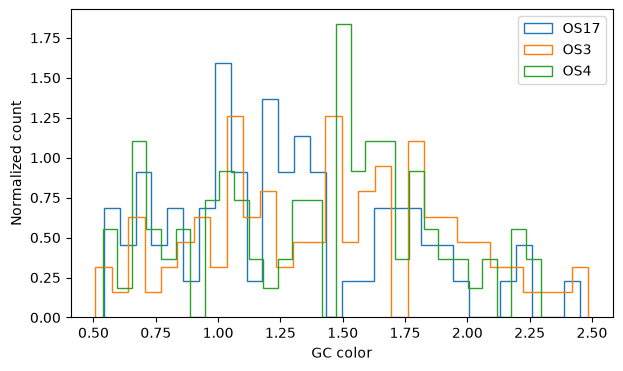

In [40]:
fig, ax = plt.subplots(figsize=(7, 4))

for pointing, group in outer_gc.groupby("pointing"):
    ax.hist(
        group[cols.gc_color],
        bins=30,
        histtype="step",
        label=pointing,
        density=True,
    )

ax.set_xlabel("GC color")
ax.set_ylabel("Normalized count")
ax.legend()

plt.show()

In [41]:
peng_like = outer_df[
    (outer_df[cols.gc_mag] < 26.5)
    & (outer_df[cols.gc_color] > 0.6)
    & (outer_df[cols.gc_color] < 1.5)
].copy()


In [42]:
print(
    peng_like["pointing"]
    .value_counts()
    .sort_index()
)

print()
print("Total:", len(peng_like))


pointing
OS17    51
OS3     52
OS4     45
Name: count, dtype: int64

Total: 148


In [43]:
pblue_peng_like, _ = compute_Pblue(
    peng_like[cols.gc_mag].to_numpy(),
    peng_like[cols.gc_color].to_numpy(),
)

peng_like["Pblue"] = pblue_peng_like

print(
    peng_like.groupby("pointing")["Pblue"]
    .agg(["count", "mean", "std", "median"])
)

print()
print(
    peng_like["Pblue"]
    .agg(["count", "mean", "std", "median"])
)


          count      mean       std    median
pointing                                     
OS17         44  0.729375  0.156367  0.777768
OS3          49  0.731701  0.129971  0.774777
OS4          43  0.691187  0.165256  0.762065

count     136.000000
mean        0.718139
std         0.150432
median      0.770902
Name: Pblue, dtype: float64


Applying the Peng et al. magnitude and color cuts to the Madrid et al. outer-field catalog yields 136 candidates with finite $P_{\rm blue}$ values across OS3, OS4, and OS17. The field means are 0.732, 0.691, and 0.729, respectively, giving a combined mean $\langle P_{\rm blue}\rangle_{\rm fg/bg}=0.718$. Although the candidate counts remain higher than those reported by Peng et al., likely because their full morphology and quality cuts cannot be reproduced exactly, the field-to-field consistency suggests that the derived color-mixture parameter is reasonably stable.

In [44]:
PBLUE_BG = 0.718139
PBLUE_BG_GRID = [0.65, 0.72, 0.80]
